## Data & Helper Functions

In [ ]:
import pandas as pd
import datetime as dt
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
#used unicodedata to remove accents/special characters from team names
import unicodedata


# reading the data from the excel file 

#CHANGE THIS LINE TO MATCH YOUR FILE PATH
file = r"C:\Users\nitya\Downloads\fifa-optimization\cleaned_data.xlsx"

schedule_current = pd.read_excel(file, sheet_name="Current Schedule")
weather_canada_df = pd.read_excel(file, sheet_name="Weather Canada")
weather_us_df = pd.read_excel(file, sheet_name="Weather US")
weather_mexico_df = pd.read_excel(file, sheet_name="Weather Mexico")
stadiums_df = pd.read_excel(file, sheet_name="Host Cities")
stadiums_current = pd.read_excel(file, sheet_name="Host Cities")
timezone_df = pd.read_excel(file, sheet_name="Time Zone")
# distance matrix from finalized Excel file
distance_df = pd.read_excel("MSE 232 Data.xlsx", sheet_name="Distance Matrix", skiprows=2,index_col=0)
teams_df = pd.read_excel(file, sheet_name="Rankings")
host = pd.read_excel("MSE 232 Data.xlsx", sheet_name="Host Cities")

# Rename columns by position (avoids exact-header-match issues)
teams_df.columns = ["Team", "Confederation", "Rank", "Points", "Host"]
host.columns = ["Abbr", "City", "Country", "Stadium", "Lat", "Lon", "Elevation", "Capacity", "RoofType"]


# Remove extra spaces from column names
for df in [ weather_canada_df, weather_us_df,
           weather_mexico_df, stadiums_df, schedule_current, stadiums_current, timezone_df, distance_df, teams_df, host]:
    df.columns = df.columns.str.strip()

# Combine weather data, used AI to learn how to this step, and converting to datetime step
weather_df = pd.concat([weather_canada_df, weather_us_df, weather_mexico_df],ignore_index=True)

#setting the given start and end dates and resonable start times
start_date = dt.date(2026, 6, 11)
end_date = dt.date(2026, 6, 27)

# Set of Dates: creating list of all possible dates beterrn June 11 and June 27, 2026, inclusive, to be used in the model
dates = []

current_date = start_date

while current_date <= end_date:
    dates.append(current_date)
    current_date += dt.timedelta(days=1)

# Possible kickoff hours set
kickoff_hours = list(range(12, 22))

schedule_current["Kickoff (Datetime)"] = pd.to_datetime(schedule_current["Kickoff (Datetime)"])

## Current Schedule Analysis

### Current Distance Analysis

                      Team  Total Travel
16                   Egypt         391.2
33                Paraguay         504.6
32                  Panama         540.1
38                 Senegal         540.1
18                  France         545.5
31                  Norway         547.8
26          Korea Republic         644.6
1                Argentina         739.0
27                  Mexico         951.8
23                    Iraq         952.5
41                  Sweden        1028.9
14           Côte d'Ivoire        1088.8
20                   Ghana        1094.2
2                Australia        1329.3
29             Netherlands        1421.0
21                   Haiti        1475.8
35                   Qatar        1519.1
34                Portugal        1547.1
22                 IR Iran        1553.1
43                 Tunisia        1582.2
24                   Japan        1688.4
30             New Zealand        1748.5
28                 Morocco        1749.7
6               

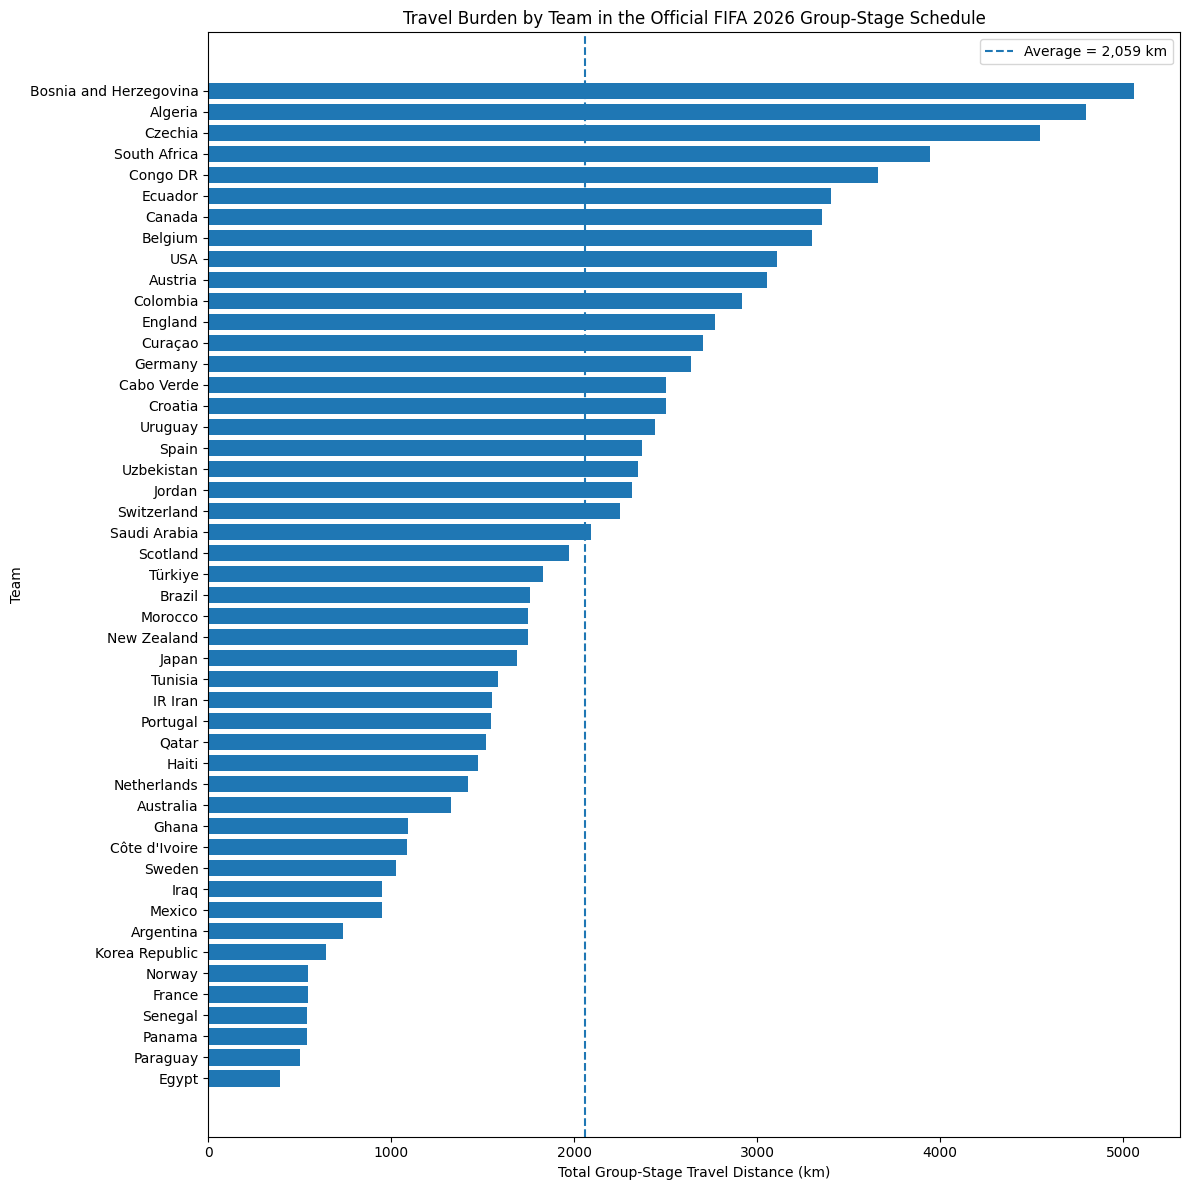

In [200]:
# Create a dictionary to match each city to its abbreviated name
city_to_abbr = dict(zip(host["City"],host["Abbr"]))

# Match the city names used in the current schedule to the abbreviations
city_to_abbr.update({
    "Atlanta": "ATL",
    "Arlington": "DAL",
    "Boston": "BOS",
    "Dallas": "DAL",
    "Foxborough": "BOS",
    "Guadalajara": "GDL",
    "Houston": "HOU",
    "Kansas City": "KC",
    "Los Angeles": "LA",
    "Mexico City": "MEX",
    "Miami": "MIA",
    "Monterrey": "MTY",
    "New Jersey": "NYNJ",
    "New York New Jersey": "NYNJ",
    "Philadelphia": "PHI",
    "Santa Clara": "SF",
    "Seattle": "SEA",
    "Toronto": "TOR",
    "Vancouver": "VAN"
})

# Formula for travel calculation for each team: 
# (distance from game venue 1 to game venue 2) 
#                    + 
# (distance from game venue 2 to game venue 3)

team1 = set(schedule_current["Team 1"].dropna())
team2 = set(schedule_current["Team 2"].dropna())

teams = sorted(team1 | team2)


team_travel = []
team_summary = []

for team in teams:

    # Find all 3 matches for the team
    team_matches = schedule_current[(schedule_current["Team 1"] == team) | (schedule_current["Team 2"] == team)].copy()

    # Put the matches in chronological order
    ordered_team_matches = team_matches.sort_values("Kickoff (Datetime)")

    # Create a list of the 3 cities the team plays in
    cities = ordered_team_matches["City"].tolist()
    
    # Convert the city names into the abbreviations used in the distance matrix
    venues = [city_to_abbr[city] for city in cities]
    
    # Calculate the distance travelled between game 1 and game 2
    leg_1 = distance_df.loc[venues[0], venues[1]]
    
    # Do the same for games 2 and 3
    leg_2 = distance_df.loc[venues[1], venues[2]]
    
    total_travel = leg_1 + leg_2

    # Store the detailed travel information for each team
    team_travel.append({
        "Team": team,
        "Game 1 Venue": venues[0],
        "Game 2 Venue": venues[1],
        "Game 3 Venue": venues[2],
        "Leg 1 Distance": leg_1,
        "Leg 2 Distance": leg_2,
        "Total Travel": total_travel
    })

    # Store a separate summary with only the team and total travel
    team_summary.append({
        "Team": team,
        "Total Travel": total_travel
    })


# Convert team_travel_summary into a dataframe
team_summary_df = pd.DataFrame(team_summary)

# Sort travel distances from least to most
team_summary_df = team_summary_df.sort_values("Total Travel")

# Plot graph

# Print the travel summary
print(team_summary_df)

# Calculate the total travel distance across all 48 teams
total_fifa_travel = team_summary_df["Total Travel"].sum()

print("Total travel across all teams:", total_fifa_travel)

# Calculate the average travel distance per team
average_travel = team_summary_df["Total Travel"].mean()

print("Average travel per team:", average_travel)

# Create a graph showing the total travel distance for each team
plt.figure(figsize=(12, 12))

plt.barh(team_summary_df["Team"],team_summary_df["Total Travel"])

# Add a line showing the average travel distance
plt.axvline(average_travel, linestyle="--", label=f"Average = {average_travel:,.0f} km")


plt.xlabel("Total Group-Stage Travel Distance (km)")
plt.ylabel("Team")

plt.title("Travel Burden by Team in the Official FIFA 2026 Group-Stage Schedule")

plt.legend()
plt.tight_layout()

plt.show()



### Current Timezone Analysis

Time Zone Shift Summary - Current Schedule
                  Team  Total Time Zone Shift
               Algeria                      4
               Czechia                      4
          South Africa                      4
                Canada                      3
              Congo DR                      3
Bosnia and Herzegovina                      3
               Austria                      2
              Colombia                      2
                 Japan                      2
               Uruguay                      2
            Uzbekistan                      2
                 Spain                      2
                Jordan                      2
               Ecuador                      2
            Cabo Verde                      1
               Croatia                      1
               Tunisia                      1
          Saudi Arabia                      1
              Portugal                      1
                Sweden               

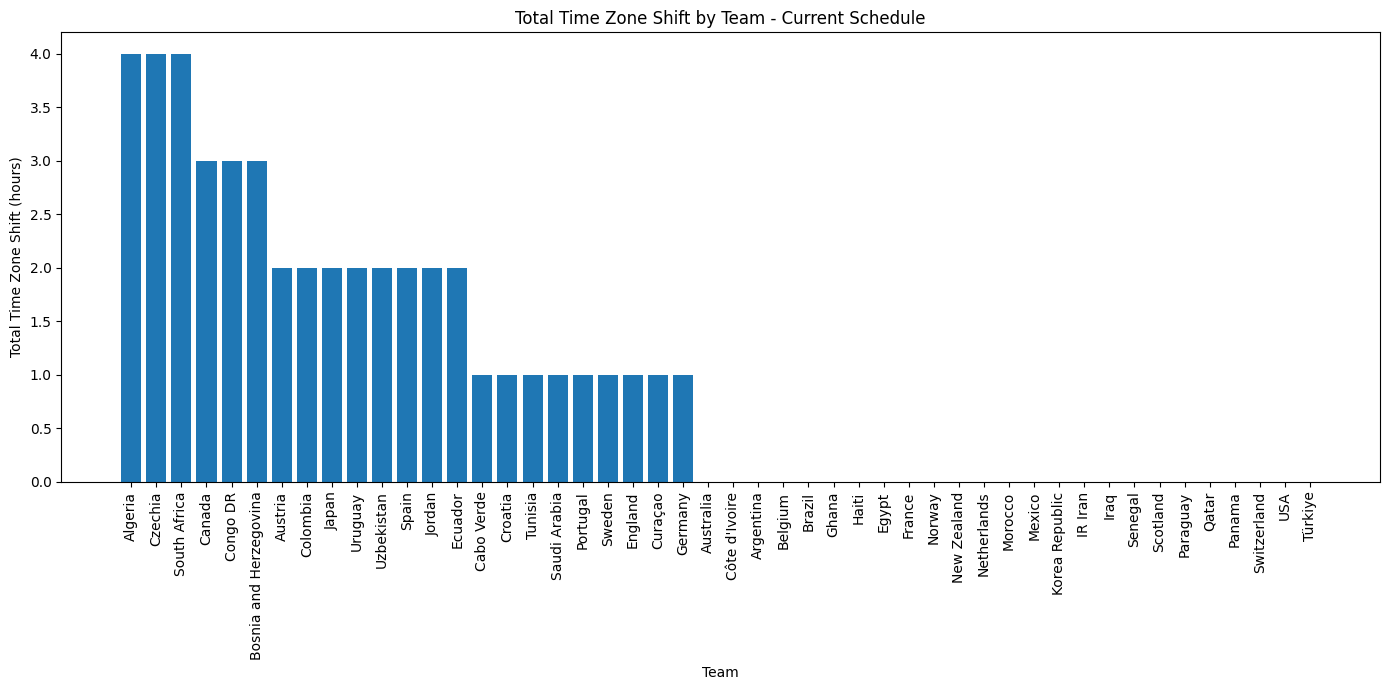

In [ ]:
# Time zone Shift Calculation

def timezone_shift(offsets):

    offsets = offsets.tolist()

    shift = 0

    for i in range(1,len(offsets)):
        shift += abs(offsets[i]-offsets[i-1])

    return shift


team_timezone_rows = []

for index, row in schedule_current.iterrows():

    # Team 1
    team_timezone_rows.append({
        "Team": row["Team 1"],
        "Match_ID": row["Match_ID"],
        "Kickoff": row["Kickoff (Datetime)"],
        "UTC Offset": row["UTC Offset Hours"]
    })

    # Team 2
    team_timezone_rows.append({
        "Team": row["Team 2"],
        "Match_ID": row["Match_ID"],
        "Kickoff": row["Kickoff (Datetime)"],
        "UTC Offset": row["UTC Offset Hours"]
    })


team_timezone_df = pd.DataFrame(team_timezone_rows)


timezone_results = []

for team, team_data in team_timezone_df.groupby("Team"):

    # Make sure matches are chronological
    team_data = team_data.sort_values("Kickoff")

    offsets = team_data["UTC Offset"]

    total_shift = timezone_shift(offsets)

    timezone_results.append({"Team": team, "Total Time Zone Shift": total_shift})


timezone_summary = pd.DataFrame(timezone_results)


# Sort from highest to lowest timezone shift
timezone_summary = timezone_summary.sort_values("Total Time Zone Shift", ascending=False)


print("Time Zone Shift Summary - Current Schedule")

print(timezone_summary.to_string(index=False))

timezone_summary.to_csv("current_schedule_timezone_shift.csv",index=False)

plt.figure(figsize=(14, 7))
plt.bar(timezone_summary["Team"],timezone_summary["Total Time Zone Shift"])
plt.title("Total Time Zone Shift by Team - Current Schedule")
plt.xlabel("Team")
plt.ylabel("Total Time Zone Shift (hours)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("current_schedule_timezone_shift.png",dpi=300,bbox_inches="tight")

plt.show()


## Model 1

In [ ]:
def model1(teams_df):
    # Set of teams
    teams_list = teams_df["Team"].tolist()

    # Create a list of groups A-L (12 groups)
    groups = [f"Group_{chr(65+i)}" for i in range(12)]

    # Create dictionaries for points and confederation
    points = teams_df.set_index("Team")["Points"].to_dict()
    confed = teams_df.set_index("Team")["Confederation"].to_dict()

    # Target range found from the data by taking the average of the top 12 teams and subtracting the average of the bottom 12 teams
    sorted_points = sorted(points.values(), reverse=True)
    tier1 = sorted_points[0:12]
    tier4 = sorted_points[36:48]
    target_range = (sum(tier1) / len(tier1)) - (sum(tier4) / len(tier4))

    model = gp.Model("GroupAssignment")

    # Decision Varaible: x[t,g] = 1 if team t is assigned to group g
    x = model.addVars(teams_list, groups, vtype=GRB.BINARY, name="x")

    # Every team is assigned to exactly one group
    for t in teams_list:
        model.addConstr(gp.quicksum(x[t, g] for g in groups) == 1)

    # Every group has exactly 4 teams
    for g in groups: 
        model.addConstr(gp.quicksum(x[t, g] for t in teams_list) == 4)

    # Confederation limits
    confederations = teams_df["Confederation"].unique().tolist()

    # Create a dictionary for confederation capacities
    CONF_CAP = {}
    for c in confederations:
        if c == "UEFA":
            CONF_CAP[c] = 2
        else:
            CONF_CAP[c] = 1

    # Every group has at most the allowed number of teams from each confederation
    for c in confederations:
        for g in groups:
            model.addConstr(gp.quicksum(x[t, g] for t in teams_list if confed[t] == c) <= CONF_CAP[c])

    # Hosts
    host_group_map = {
        "Canada": "Group_A",
        "Mexico": "Group_B",
        "USA": "Group_C"
    }

    # Each host is assigned to its designated group
    for t in host_group_map:
        model.addConstr(x[t, host_group_map[t]] == 1)


    # GROUP AVERAGES
    # Continuous variable representing each group's average point total
    group_avg = model.addVars(groups, lb=0, vtype=GRB.CONTINUOUS, name="group_avg")

    # group average equal to the sum of points of the teams in that group divided by 4
    for g in groups:
        model.addConstr(group_avg[g] == gp.quicksum(points[t] * x[t, g] for t in teams_list) / 4)

    # Highest and lowest group averages
    max_avg = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="max_avg")
    min_avg = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="min_avg")

    # tracks the maximum and minimum group averages so that the difference can be minimized in the objective function
    for g in groups:
        model.addConstr(max_avg >= group_avg[g]) 
        model.addConstr(min_avg <= group_avg[g]) 


    # GROUP RANGES
    # Continuous variables representing each group's maximum and minimum point totals
    group_max = model.addVars(groups, lb=0, vtype=GRB.CONTINUOUS, name="group_max")
    group_min = model.addVars(groups, lb=0, vtype=GRB.CONTINUOUS, name="group_min")

    M = 10000 # big-M constant to turn off the minimum constraint when a team is not assigned to a group

    # goes through each team in each group and gets the maximum and minimum point totals for that group
    for g in groups:
        for t in teams_list:
            model.addConstr(group_max[g] >= points[t] * x[t, g]) #group's maximum has to be greater than the current team's points if that team is assigned to the group
            
            #when the decision variable is 1, the constraint is active because M is multiplied by 0 and doesn't get added, when the decision varaible is 0, the constraint is not active because M gets added 
            model.addConstr(group_min[g] <= points[t] * x[t, g] + M * (1 - x[t, g])) # group's minimum has to be less than the current team's points if that team is assigned to the group
            

    # continuous variable for the range of each group
    group_range = model.addVars(groups, lb=0, vtype=GRB.CONTINUOUS, name="group_range")

    # goes through each group and calculates the range of that group 
    for g in groups:
        model.addConstr(group_range[g] == group_max[g] - group_min[g])

    # variable for how far each group's range is from the target range
    range_deviation = model.addVars(groups, lb=0, vtype=GRB.CONTINUOUS, name="range_deviation")

    # goes through each group and calculates the deviation of the range of that group from the target range 
    for g in groups:
        model.addConstr(range_deviation[g] >= group_range[g] - target_range)
        model.addConstr(range_deviation[g] >= target_range - group_range[g])


    # OBJECTIVE
    # the objective function minimizes the difference between the maximum and minimum group averages as well as the sum of the range deviations for each group
    # it prioritizes minimizing the difference in group averages by multiplying it by 15 
    w1 = 15
    w2 = 1
    model.setObjective(w1 * (max_avg - min_avg)+ w2 * gp.quicksum(range_deviation[g] for g in groups),GRB.MINIMIZE)

    #optimization parameters 
    model.setParam("TimeLimit", 900)# sets time limit of 15 minutes 
    model.setParam("MIPGap", 0.01) # sets the MIP gap to 1% to allow for a near-optimal solution if the time limit is reached

    #optimize the model
    model.optimize()


    # RESULTS
    # prints results to CSV file called "team_groups.csv"
    print("Model status:", model.status)
    print("Number of solutions found:", model.SolCount)

    if model.SolCount > 0:

        print("\nBest feasible group assignments:")

        results = []

        for t in teams_list:
            for g in groups:
                if x[t, g].X > 0.5:
                    results.append({
                        "Team": t,
                        "Group": g,
                        "Points": points[t]
                    })

        result_df = pd.DataFrame(results)
        print(result_df.sort_values("Group"))

        # save team-group assignments to CSV
        result_df.to_csv("team_groups.csv", index=False)

        print("\nGroup averages and ranges:")

        for g in groups:
            print(
                f"{g}: "
                f"Average = {group_avg[g].X:.2f}, "
                f"Range = {group_range[g].X:.2f}"
            )

        print(f"\nAverage spread: {max_avg.X - min_avg.X:.2f}")

        print("\nRange deviations from target:")

        for g in groups:
            print(
                f"{g}: "
                f"{range_deviation[g].X:.2f}"
            )

        if model.status == GRB.OPTIMAL:
            print("\nProven optimal.")
        elif model.status == GRB.TIME_LIMIT:
            print("\nTime limit reached. Best solution found, but it may not be globally optimal.")

    else:
        print("No feasible solution found.")

In [156]:
model1(teams_df)

Set parameter TimeLimit to value 900
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  900
MIPGap  0.01

Optimize a model with 1359 rows, 638 columns and 4755 nonzeros (Min)
Model fingerprint: 0xf84d6813
Model has 14 linear objective coefficients
Variable types: 62 continuous, 576 integer (576 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+03]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]

Presolve removed 713 rows and 48 columns
Presolve time: 0.02s
Presolved: 646 rows, 590 columns, 5791 nonzeros
Variable types: 59 continuous, 531 integer (531 binary)

Root relaxation: objective 0.000000e+00, 512 iterations, 0.01 seconds (0.02 work units)

    Nodes    | 

## Model 2

In [ ]:
#reading and cleaning data
# Team & Group assignment (taken from Model 1's solved model output (trial_1.ipynb) in the form of a .csv file)
team_groups = pd.read_csv("team_groups.csv")

# sets and parameters

# V = list of all 16 venue / stadium codes 
V = host["Abbr"].tolist() 


# stadium capacity - e.g. capacity["MEX"] = 87000
capacity = dict(zip(host["Abbr"],host["Capacity"]))


# distance table is reordered to match venue order
# then this is covered to a Python dictionary 
# e.g. distance["MEX", "TOR"] - gives distance btwn Mexico City and Toronto (in km)
distance_df = distance_df.loc[V, V]

distance = {}

for v1 in V:
    for v2 in V:
        distance[v1, v2] = float(distance_df.loc[v1, v2])


# Looks up UTC offset for each stadium/city
utc_offset = dict(zip(timezone_df["Host City (Abbreviated)"],timezone_df["Offset"]))


# 17 generic day numbers (length of World Cup - no specific dates include)
# just length of the World Cup (June 11 to June 27 = 17 days)
DAYS = list(range(1, 18))

# create the 72 matches

def circle_method_fixtures(teams):

    t = teams
    # round-robin architecture of how the order of 4 teams 
    # within a certain group play with each other (this happens in parallel across all groups)
    return {
        1: [
            (t[0], t[1]),
            (t[2], t[3])
        ],
        2: [
            (t[0], t[2]),
            (t[1], t[3])
        ],
        3: [
            (t[0], t[3]),
            (t[1], t[2])
        ]
    }

# this chunk basically loops through each group, generates the round-robin
# style that we created above for the order that they are playing,
# and records each match as a tuple with a unique ID (everything is appended to a list called matches in each iteration)
# match id is increased by 1 after every iteration based on this reasoning
groups_all = sorted(team_groups["Group"].unique())


matches = []

match_id = 0

for g in groups_all:
    teams_in_group = sorted(team_groups.loc[team_groups["Group"] == g, "Team"].tolist())

    fixtures = circle_method_fixtures(teams_in_group)

    for r in [1, 2, 3]:
        for team1, team2 in fixtures[r]:
            matches.append((match_id,g,r,team1,team2))
            match_id += 1

# list of match IDs [0,1,.....,71]
M = [match[0] for match in matches]

print("Number of matches:", len(M))

# this dictionary will have information about each match
match_info = {}

# this loop iterates through the match list and adds each teams info
# including the match id, group, round, team1, and team2 to the dictionary
for match in matches:

    m, g, r, team1, team2 = match # this unpacks each tuple within the match list to get the info we need

    match_info[m] = {
        "Group": g,
        "Round": r,
        "Team1": team1,
        "Team2": team2
    }

# takes the list of all team names, drops any duplicates, 
# and sorts them in alphabetical order
teams_all = sorted(team_groups["Team"].unique())

# team_matches[t] contains the 3 matches
# played by team t

team_matches = {}

for t in teams_all:
    # all teams start of with empty slots for each round
    team_matches[t] = [None,None,None]

# go through every one of the 72 matches, and write down the match ID for each team (where m is)
# e.g. for match (0, "Group A", 1, "Canada", "Saudi Arabia")
# go to Canada's position (r-1) -> Round 1, slot 0 and write down match ID 0 there
# do the same for team 2, aka Saudi Arabia
for m, g, r, team1, team2 in matches:
    team_matches[team1][r - 1] = m
    team_matches[team2][r - 1] = m

# Check that every team has 3 matches
for t in teams_all:

# assert was something we learned in MSE 240 (used here to do the sanity check)
    assert None not in team_matches[t] 

print("Number of teams:", len(teams_all))
print("All teams have 3 matches.")


# Model 2

def model2():

    model = gp.Model("FIFA_Model_2")

    # parameters
    MIN_REST = 3

    MAX_TZ_SHIFT = 1

    MAX_MATCHES_PER_DAY = 8

    # Weights for goal programming
    W_REST = 50
    W_TZ = 100

    # Capacity weight
    W_CAP = 0.01

    # decision variables

    # Y[m,v] = 1 if match m is played at venue v
    Y = model.addVars(M,V,vtype=GRB.BINARY,name="Y")

    # S[m,k] = 1 if match m is played on day k
    S = model.addVars(M,DAYS,vtype=GRB.BINARY,name="S")

    # Constraint 1: Every match gets exactly one stadium
    for m in M:
        model.addConstr(gp.quicksum(Y[m, v] for v in V) == 1)

    # Contraint 2: Every match gets exactly one day
    for m in M:
        model.addConstr(gp.quicksum(S[m, k] for k in DAYS) == 1)

    # Constraint 3: Maximum number of matches per day
    for k in DAYS:
        model.addConstr(gp.quicksum(S[m, k] for m in M) <= MAX_MATCHES_PER_DAY)



    # BUG FIX: without a cap on matches per venue, nothing stops
    # the solver from dumping a whole group's matches into 1-2 big
    # stadiums to get travel distance down to zero. This is why
    # DAL and NYNJ each ended up hosting 17 of the 72 matches while
    # PHI and HOU got just 1 each. Proportional to stadium size,
    # same logic as our Model 1 test version (average ~4.5/venue).

    avg_matches_per_venue = 72 / len(V)
    mean_cap = sum(capacity.values()) / len(V)
    venue_match_cap = {
        v: max(3, round(capacity[v] / mean_cap * avg_matches_per_venue)) for v in V
    }

    for v in V:
        model.addConstr(gp.quicksum(Y[m, v] for m in M) <= venue_match_cap[v])

    # Constraint 4: Matches within a group must occur in round order
    # get the match IDs for each group and round
    group_round_match = {}

    for m, g, r, team1, team2 in matches:
        group_round_match[g, r] = []


    # We add matches one at a time below
    # add each match ID one at a time into the right group-round's (pair) list
    for m, g, r, team1, team2 in matches:
        group_round_match[g, r].append(m)

    # Calculate the day of each individual match
    match_day = {}

    # e.g. match_day[17] might come out to 5
    # which means match 17 is scheduled on day 5
    for m in M:
        match_day[m] = gp.quicksum(k * S[m, k] for k in DAYS)

    # For each group, Round 2 must occur after Round 1
    # and Round 3 must occur after Round 2
    
    # Note to self:
    # The two matches in the same round don't have to occur on the same day

    for g in groups_all:
        # Every Round 2 match must be after every
        # Round 1 match for this group
        for m2 in group_round_match[g, 2]:
            for m1 in group_round_match[g, 1]:
                model.addConstr(match_day[m2] >= match_day[m1] + 1)


        # Every Round 3 match must be after every
        # Round 2 match

        for m3 in group_round_match[g, 3]:
            for m2 in group_round_match[g, 2]:
                model.addConstr(match_day[m3] >= match_day[m2] + 1)


    # team travel distance and timezones

    # Z[t,r,v1,v2] = 1 if team t plays round r
    # at venue v1 and round r+1 at venue v2

    Z = model.addVars(teams_all,[1, 2],V,V, vtype=GRB.BINARY, name="Z")


    # Link Z to the stadium assignments

    for t in teams_all:
        for r in [1, 2]:
            m1 = team_matches[t][r - 1] # team t's match at the start of the leg
            m2 = team_matches[t][r] # team t's match at the end of the leg
            for v1 in V:
                for v2 in V:
                    # Z can only equal 1 if the first
                    # match is assigned to venue v1
                    model.addConstr(Z[t, r, v1, v2] <= Y[m1, v1])

                    # Z can only equal 1 if the second
                    # match is assigned to venue v2
                    model.addConstr(Z[t, r, v1, v2] <= Y[m2, v2])

                    # If both venue assignments are selected,
                    # Z must equal 1
                    model.addConstr(Z[t, r, v1, v2] >= Y[m1, v1] + Y[m2, v2]- 1)
                    # Note to self: if both of the above are true, force Z 
                    # to actually turn on (together these 3 rules make Z 
                    # behave exactly like: match1 at v1 AND match2 at v2)

   
    # BUG FIX: Need to force a team's matches in the same leg to use two different venues 
    # (if not km travelled = 0 for most teams bc all matches for most teams took place in NYNJ and DAL)
    
    # this ensures every city get to experience a match instead of most of the matches happening at same stadium
    for t in teams_all:
        for r in [1, 2]:
            m1 = team_matches[t][r - 1]
            m2 = team_matches[t][r]
            for v in V:
                model.addConstr(Y[m1, v] + Y[m2, v] <= 1)


    # H = 1 if match m is played on stadium k on day d
    H = model.addVars(M, V, DAYS,vtype=GRB.BINARY, name="H")

    #similar to Z, linking to stadium assignments
    for m in M:
        for v in V:
            for k in DAYS:
            
                model.addConstr(H[m,v,k] <= Y[m,v])

                model.addConstr(H[m,v,k] <= S[m,k])

                model.addConstr(H[m,v,k] >= Y[m,v] + S[m,k] - 1)

    # Each stadium hosts at most one match per day
    for v in V:
        for k in DAYS:
            model.addConstr(gp.quicksum(H[m,v,k]for m in M) <= 1)

    # Dist[t,r] = distance travelled by team t
    # between round r and round r+1

    Dist = model.addVars(teams_all, [1, 2], lb=0, name="Dist")


    # TZ[t,r] = timezone shift between
    # round r and round r+1

    TZ = model.addVars(teams_all,[1, 2],lb=0,name="TZ")


    # Calculate travel distance using the selected
    # pair of venues

    for t in teams_all:
        for r in [1, 2]:
            model.addConstr(Dist[t, r] == gp.quicksum(distance[v1, v2]* Z[t, r, v1, v2] for v1 in V for v2 in V))

    # Calculate timezone shift using the selected
    # pair of venues
    for t in teams_all:
        for r in [1, 2]:
            model.addConstr(TZ[t, r] == gp.quicksum(abs(utc_offset[v1]- utc_offset[v2]) * Z[t, r, v1, v2] for v1 in V for v2 in V))

    # Team-specific rest

    # Since matches now have their own days,
    # we calculate rest for each team separately

    # how many days over the rest target 
    # this team ended up with (not penalized)
    rest_plus = model.addVars(teams_all, [1, 2], lb=0, name="rest_plus")

    # how many days short of the rest target 
    # this team ended up with (this gets penalized)
    rest_minus = model.addVars(teams_all,[1, 2],lb=0,name="rest_minus")


    for t in teams_all:
        for r in [1, 2]:
            m1 = team_matches[t][r - 1]
            m2 = team_matches[t][r]

            # Difference between the actual match days
            rest = (match_day[m2]- match_day[m1])

            # ties the real gap to the target - e.g. if it's short of 3 days,
            # rest_minus soaks up the difference so the equation still balances

            model.addConstr(rest - (rest_plus[t, r] - rest_minus[t, r])== MIN_REST)


    # timezone goal
    # how many hours over the timezone target 
    # this team ended up with (this gets penalized)
    tz_plus = model.addVars(teams_all,[1, 2], lb=0, name="tz_plus")

    # how many hours under the timezone 
    # target this team ended up with (not penalized)
    tz_minus = model.addVars(teams_all,[1, 2], lb=0, name="tz_minus")


    for t in teams_all:

        for r in [1, 2]:
            # ties the real timezone shift to the target, same pattern as rest
            model.addConstr(TZ[t, r]- (tz_plus[t, r]- tz_minus[t, r]) == MAX_TZ_SHIFT)


    # Objective
    # adds up every team's travel distance across both legs
    total_travel = gp.quicksum(Dist[t, r] for t in teams_all for r in [1, 2])

    # adds up all the rest shortfall penalties
    total_rest_penalty = gp.quicksum(rest_minus[t, r] for t in teams_all for r in [1, 2])

    # adds up all the timezone-excess penalties
    total_tz_penalty = gp.quicksum(tz_plus[t, r] for t in teams_all for r in [1, 2])


    # We want to favour larger stadiums
    
    # Since we are minimizing, we subtract capacity
    # from the objective.

    # adds up the seat capacity of whichever venue each match actually used
    # (bigger stadiums used = bigger number here)
    capacity_reward = gp.quicksum(capacity[v] * Y[m, v] for m in M for v in V)

    # minimize travel + goal penalties, 
    # minus a small reward for using bigger stadiums
    model.setObjective(total_travel + W_REST * total_rest_penalty + W_TZ * total_tz_penalty - W_CAP * capacity_reward, GRB.MINIMIZE)

    # settings for the solver

    # run the model for max. 30 mins
    model.setParam("TimeLimit",1800)

    # solve

    model.optimize()

    # output


    if model.SolCount > 0:

        print("\nModel solved.")

        print("Objective value:", round(model.ObjVal, 2))

        # Get stadium for every match

        match_venue = {}

        for m in M:
            for v in V:
                if Y[m, v].X > 0.5:
                    match_venue[m] = v
                    break

        # Get day for every match
        match_days = {}
        for m in M:
            for k in DAYS:
                if S[m, k].X > 0.5:
                    match_days[m] = k
                    break

        # create schedule dataframe so that we can work with pandas
        schedule_rows = []
        for m, g, r, team1, team2 in matches:
            schedule_rows.append({
                "Match_ID": m,
                "Group": g,
                "Round": r,
                "Team 1": team1,
                "Team 2": team2,
                "Day": match_days[m],
                "Stadium": match_venue[m],
                "City": host.loc[host["Abbr"] == match_venue[m],"City"].iloc[0],
                "Capacity": capacity[match_venue[m]],
                "Host City (Abbreviated)": host.loc[host["Abbr"] == match_venue[m],"Abbr"].iloc[0]
            })

        schedule_df = pd.DataFrame(schedule_rows)
        schedule_df = schedule_df.sort_values(["Day", "Stadium"])

        print("\nOptimized schedule:")
        print(schedule_df.head(20))

        # team summary

        team_rows = []

        for t in teams_all:
            match1 = team_matches[t][0]
            match2 = team_matches[t][1]
            match3 = team_matches[t][2]

            # Total travel
            total_distance = (Dist[t, 1].X + Dist[t, 2].X)

            # Total timezone shift
            total_timezone = (TZ[t, 1].X + TZ[t, 2].X)

            # Actual rest
            rest1 = (match_days[match2]- match_days[match1])

            rest2 = (match_days[match3]- match_days[match2])

            group = team_groups.loc[team_groups["Team"] == t,"Group"].iloc[0]

            team_rows.append({

                "Team": t,

                "Group": group,

                "Travel_km": round(total_distance,1),

                "Timezone_Shift_hours": round(total_timezone, 1),

                "Rest_R1_R2": rest1,

                "Rest_R2_R3": rest2,

                "Minimum_Rest": min(rest1,rest2)
            })


        team_df = pd.DataFrame(team_rows)


        print("\nTeam summary:")

        print(team_df.sort_values("Travel_km",ascending=False).head(10))

        # overall results

        print("\nOverall results:")

        print(
            "Total travel:",round(team_df["Travel_km"].sum(),1),"km")

        print("Teams below", MIN_REST, "days rest:", (team_df["Minimum_Rest"]< MIN_REST).sum())


        print("Teams with timezone shift above",MAX_TZ_SHIFT,"hours per leg:", (team_df["Timezone_Shift_hours"] > 2 * MAX_TZ_SHIFT).sum())


        # save the final results as a csv

        schedule_df.to_csv("schedule_model2.csv",index=False)

        team_df.to_csv("team_summary_model2.csv", index=False)


        print( "\nFiles saved successfully.")

        return schedule_df, team_df

    else:

        print("No feasible solution found.")

Number of matches: 72
Number of teams: 48
All teams have 3 matches.


In [167]:
model2()

Set parameter TimeLimit to value 1800
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  1800

Optimize a model with 134945 rows, 47112 columns and 384624 nonzeros (Min)
Model fingerprint: 0x3bf0bacc
Model has 1440 linear objective coefficients
Variable types: 576 continuous, 46536 integer (46536 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+03]
  Objective range  [1e+00, 9e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+00]

Presolve removed 22176 rows and 4272 columns
Presolve time: 2.39s
Presolved: 112769 rows, 42840 columns, 307152 nonzeros
Variable types: 192 continuous, 42648 integer (42648 binary)

Deterministic concurrent LP optimizer: primal and dual simplex (primal and dual model)
Showing primal log only...

Root r

(    Match_ID    Group  Round        Team 1   Team 2  Day Stadium  \
 48        48  Group_I      1     Argentina  Czechia    1     ATL   
 18        18  Group_D      1       Curacao  Germany    1     BOS   
 25        25  Group_E      1         Japan  Senegal    1     GDL   
 61        61  Group_K      1  South Africa   Sweden    1      KC   
 13        13  Group_C      1           USA  Uruguay    1     MEX   
 ..       ...      ...    ...           ...      ...  ...     ...   
 17        17  Group_C      3   Switzerland      USA   17     MEX   
 47        47  Group_H      3      Scotland    Spain   17     MIA   
 29        29  Group_E      3         Haiti    Japan   17     MTY   
 23        23  Group_D      3       Germany  Morocco   17     PHI   
 70        70  Group_L      3       Algeria    Qatar   17     VAN   
 
              City  Capacity Host City (Abbreviated)  
 48        Atlanta     75000                     ATL  
 18    Foxborough)     65000                     BOS  
 25  

In [ ]:
# this function removes any special characters or accents from team names (e.g. México" to Mexico)
def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))


## Model 3

In [ ]:
#convert to datetime type
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

# reading first csv from model 2
schedule_model2 = pd.read_csv("schedule_model2.csv")

matches_model2 = schedule_model2["Match_ID"].tolist()

teams_of_match = {}

#loops through the schedule dataframe to create a dictionary of match IDs and their corresponding teams: 
# https://www.datacamp.com/tutorial/pandas-iterate-over-rows
for index, row in schedule_model2.iterrows():
    teams_of_match[row["Match_ID"]] = (row["Team 1"], row["Team 2"])


match_group = dict(zip(schedule_model2["Match_ID"],schedule_model2["Group"]))

# pairing match IDs with stadium IDs from model 2 output
match_stadium = dict(zip(schedule_model2["Match_ID"],schedule_model2["Stadium"]))

#pairing match IDs with city names and city abbreviations from model 2 output
match_city = dict(zip(schedule_model2["Match_ID"],schedule_model2["City"]))

match_city_abbr = dict(zip(schedule_model2["Match_ID"],schedule_model2["Host City (Abbreviated)"]))


# pairing the stadium ids with their corresponding roof types (indoor or outdoor), 1 for indoor and 0 for outdoor
roof_type = dict(zip(stadiums_df["Host City (Abbreviated)"], stadiums_df["Stadium Roof Type"]))


# setting 1 = indoor / climate-controlled & 0 = outdoor

indoor = {}

for city_abbr, roof in roof_type.items():

    if roof == "Retractable (Climate-Controlled)":
        indoor[city_abbr] = 1
    else:
        indoor[city_abbr] = 0


#pairing the weather data with the corresponding city, date, and hour to be used in the model
weather_df["date"] = weather_df["datetime"].dt.date
weather_df["hour"] = weather_df["datetime"].dt.hour

#weather set
weather = {}

for index, row in weather_df.iterrows():
    city = row["City"]
    date = row["date"]
    hour = row["hour"]
    weather[city, date, hour] = {
        "temp": row["temp"],
        "humidity": row["humidity"],
        "rain": row["precip"]}


#setting weather score, penalty for temperature, humidity, and rain precipitation, with indoor stadiums having a score of 0

def weather_score(temp, humidity, rain):

    score = 0

    # temperature
    if temp > 28:
        score += 2
    elif temp >= 22:
        score += 1

    elif temp < 10:
        score += 2
    
    elif temp < 15:
        score += 1

    # Humidity
    if humidity > 60:
        score += 2

   # Rainfall (mm)
    if rain > 5:
        score += 2
    elif rain > 0:
        score += 1

    return score


In [ ]:
# reading second csv from model 2
rest_df = pd.read_csv("team_summary_model2.csv")

minimum_rest = dict(zip(rest_df["Team"], rest_df["Minimum_Rest"]))


def model3 (matches, match_city, match_stadium, match_city_abbr, indoor, weather, dates, kickoff_hours, teams_of_match, minimum_rest):

    # Calculate weather score for every possible match/date/time
    score = {}

    for m in matches:

        city = match_city[m]
        stadium = match_stadium[m]
        city_abbr = match_city_abbr[m]
        for d in dates:
            for h in kickoff_hours:
                if (city, d, h) in weather:
                    temp = weather[city, d, h]["temp"]
                    humidity = weather[city, d, h]["humidity"]
                    rain = weather[city, d, h]["rain"]
                    # If stadium is indoor, weather score can be zero
                    if indoor[city_abbr] == 1:
                        score[m, d, h] = 0
                    else:
                        score[m, d, h] = weather_score(temp,humidity,rain)
                else:
                    # No weather data means this time  and date cannot be used
                    score[m, d, h] = 9999

    #creating model

    model = gp.Model("Model 3 Date & Time")

    # x = 1 if match m is played on date d at hour h

    x = model.addVars(matches,dates,kickoff_hours,vtype=GRB.BINARY,name="x")

    #constraints

    # Every match must be scheduled exactly once
    for m in matches:

        model.addConstr(gp.quicksum(x[m, d, h] for d in dates for h in kickoff_hours) == 1)

    # Maximum 8 matches can be played on any day
    for d in dates:
        model.addConstr(gp.quicksum(x[m, d, h] for m in matches for h in kickoff_hours) <= 8,name=f"matches_per_day_{d}")

    # A stadium can only have one match per day
    stadiums = set(match_stadium[m] for m in matches)

    for stadium in stadiums:
        stadium_matches = [m for m in matches if match_stadium[m] == stadium]
        for d in dates:
            model.addConstr(gp.quicksum(x[m, d, h] for m in stadium_matches for h in kickoff_hours) <= 1)


    # Find matches for each team

    teams = ["Canada", "Mexico", "USA", "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bosnia and Herzegovina", "Brazil", "Cabo Verde", "Colombia", "Congo DR", "Cote d'Ivoire", "Croatia", "Curacao", "Czechia", "Ecuador"
                ,"Egypt", "England", "France", "Germany", "Ghana", "Haiti", "IR Iran", "Iraq", "Japan", "Jordan", "Korea Republic", "Morocco", "Netherlands", "New Zealand", "Norway", "Panama", "Paraguay", "Portugal", "Qatar", "Saudi Arabia", "Scotland", "Senegal",
                "South Africa", "Spain", "Sweden", "Switzerland", "Tunisia", "Turkiye", "Uruguay", "Uzbekistan"]

    # Create a dictionary to hold the matches for each team
    team_matches = {}
    for team in teams:
        team_matches[team] = []
        for m in matches:
            if team in teams_of_match[m]:
                team_matches[team].append(m)


    # Create an integer representing the date of each match so the dates can be used in the rest day constraints. The integer will be the index of the date in the dates list.

    match_date = model.addVars(matches,vtype=GRB.INTEGER,lb=0,ub=len(dates) - 1,name="match_date")


    # Link match_date to the selected date
    for m in matches:
        model.addConstr(match_date[m] == gp.quicksum(dates.index(d) * x[m, d, h] for d in dates for h in kickoff_hours))


    # Rest constraint

    for team in teams:
        team_games = team_matches[team]

        #sort according to match IDs
        team_games.sort()
        team_min_rest = minimum_rest[team]
        # constraint to ensure that the difference between the dates of two consecutive matches for a team is at least the minimum rest days
        for i in range(len(team_games) - 1):

            first_match = team_games[i]
            second_match = team_games[i + 1]

            model.addConstr(match_date[second_match] - match_date[first_match] >= team_min_rest)

    #objective

    model.setObjective(gp.quicksum(score[m, d, h] * x[m, d, h] for m in matches for d in dates for h in kickoff_hours), GRB.MINIMIZE)

    model.optimize()
   
    if model.status == GRB.OPTIMAL:

        results = []

        for m in matches:
            for d in dates:
                for h in kickoff_hours:

                    if x[m, d, h].X > 0.5:

                        city = match_city[m]
                        if (city, d, h) in weather:
                            temp = weather[city, d, h]["temp"]
                            humidity = weather[city, d, h]["humidity"]
                            rain = weather[city, d, h]["rain"]
                    

                        results.append({
                            "Match_ID": m,
                            "Group": match_group[m],
                            "Team 1": teams_of_match[m][0],
                            "Team 2": teams_of_match[m][1],
                            "Stadium": match_stadium[m],
                            "City": city,
                            "Indoor": "Yes" if indoor[match_city_abbr[m]] else "No",
                            "Date": d,
                            "Kickoff Hour": h,
                            "Temperature": temp,
                            "Humidity": humidity,
                            "Rain (mm)": rain,
                            "Weather Score": score[m, d, h]
                            
                        })

        results_df = pd.DataFrame(results)

        

        #https://www.datacamp.com/tutorial/pandas-sort-values?utm_cid=23487274749&utm_aid=192541861336&utm_campaign=230119_1-ps-dscia~dsa-tofu~python_2-b2c_3-nam_4-prc_5-na_6-na_7-le_8-pdsh-go_9-nb-e_10-na_11-na&utm_loc=9001027-&utm_mtd=-c&utm_kw=&utm_source=google&utm_medium=paid_search&utm_content=ps-dscia~nam-en~dsa~tofu~tutorial~python&gad_source=1&gad_campaignid=23487274749&gbraid=0AAAAADQ9WsEKGTuy2nCSYpPURMlvQCP31&gclid=CjwKCAjw1vXTBhB-EiwAEKr_k9PK8nIpxFjwi6Ks88jQxSqeopaMboroqM_PygWY6MtFZ14WDu8UkRoCiWcQAvD_BwE
        # source for sort_values
        results_df = results_df.sort_values(
            ["Date", "Kickoff Hour"])

        print(results_df.to_string(index=False))

        results_df.to_csv("model3_schedule_output.csv",index=False)

        print("\nSchedule saved to model3_schedule_output.csv")

        return results_df

    else:

        print("No feasible solution found.")


In [188]:
model3(matches_model2, match_city, match_stadium, match_city_abbr, indoor, weather, dates, kickoff_hours, teams_of_match, minimum_rest)
results = model3(matches_model2, match_city, match_stadium, match_city_abbr, indoor, weather, dates, kickoff_hours, teams_of_match, minimum_rest)
model3_df = pd.DataFrame(results)

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 529 rows, 12312 columns and 48504 nonzeros (Min)
Model fingerprint: 0x1500fec9
Model has 8894 linear objective coefficients
Variable types: 0 continuous, 12312 integer (12240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+00, 5e+00]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 8e+00]

Presolve removed 128 rows and 11793 columns
Presolve time: 0.15s
Presolved: 401 rows, 519 columns, 1907 nonzeros
Variable types: 0 continuous, 519 integer (454 binary)
Found heuristic solution: objective 66.0000000

Root relaxation: objective 3.574510e+01, 180 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexp

## Current Weather vs. Optimized Schdeule Weather Analysis

In [ ]:
#current schdeule wheather and temperature analysis
summary = []

schedule_current["Kickoff (Datetime)"] = pd.to_datetime(schedule_current["Kickoff (Datetime)"])

#storing current schdeule and weahter in dictionary
for index, row in schedule_current.iterrows():
    match_id = row["Match_ID"]
    team1 = row["Team 1"]
    team2 = row["Team 2"]
    city = row["City"]
    city_abbr = row["Host City (Abbreviated)"]
    kickoff = row["Kickoff (Datetime)"]
    date = kickoff.date()
    hour = kickoff.hour

    # Check whether weather data exists for this
    # city/date/hour
    if (city, date, hour) in weather:
        temp = weather[city, date, hour]["temp"]
        humidity = weather[city, date, hour]["humidity"]
        rain = weather[city, date, hour]["rain"]
        # Indoor stadiums receive weather score of 0
        if indoor[city_abbr] == 1:
            weather_penalty = 0
        else:
            weather_penalty = weather_score(temp, humidity, rain)

    else:
        # Missing weather data
        temp = None
        humidity = None
        rain = None
        weather_penalty = None

    summary.append({
        "Match_ID": match_id,
        "Team 1": team1,
        "Team 2": team2,
        "City": city,
        "Stadium": row["Stadium_ID"],
        "Indoor": "Yes" if indoor[city_abbr] == 1 else "No",
        "Kickoff": kickoff,
        "Temperature": temp,
        "Humidity": humidity,
        "Rain (mm)": rain,
        "Weather Score": weather_penalty
    })


current_weather_df = pd.DataFrame(summary)


team_rows = []

for index, row in current_weather_df.iterrows():

    #Team 1
    team_rows.append({
        "Team": row["Team 1"],
        "Match_ID": row["Match_ID"],
        "City": row["City"],
        "Stadium": row["Stadium"],
        "Kickoff": row["Kickoff"],
        "Indoor": row["Indoor"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Rain (mm)": row["Rain (mm)"],
        "Weather Score": row["Weather Score"]
    })

    #Team 2
    team_rows.append({
        "Team": row["Team 2"],
        "Match_ID": row["Match_ID"],
        "City": row["City"],
        "Stadium": row["Stadium"],
        "Kickoff": row["Kickoff"],
        "Indoor": row["Indoor"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Rain (mm)": row["Rain (mm)"],
        "Weather Score": row["Weather Score"]
    })

team_weather_df = pd.DataFrame(team_rows)
#used AI to learn how to group by team and calculate average weather conditions for each team
team_weather_summary = (
    team_weather_df.groupby("Team").agg(
        Matches=("Match_ID", "count"),
        Avg_Temperature=("Temperature", "mean"),
        Avg_Humidity=("Humidity", "mean"),
        Avg_Precipitation=("Rain (mm)", "mean"),
        Avg_Weather_Score=("Weather Score", "mean")).reset_index()
)

#Round values
team_weather_summary["Avg_Temperature"] = (team_weather_summary["Avg_Temperature"].round(2))

team_weather_summary["Avg_Humidity"] = (team_weather_summary["Avg_Humidity"].round(2))

team_weather_summary["Avg_Precipitation"] = (team_weather_summary["Avg_Precipitation"].round(2))

team_weather_summary["Avg_Weather_Score"] = (team_weather_summary["Avg_Weather_Score"].round(2))


# Sort alphabetically by team
team_weather_summary = team_weather_summary.sort_values("Team")

print(team_weather_summary.to_string(index=False))

                  Team  Matches  Avg_Temperature  Avg_Humidity  Avg_Precipitation  Avg_Weather_Score
               Algeria        3            23.17         67.50               0.00               2.33
             Argentina        3            30.87         50.61               0.00               0.33
             Australia        3            24.50         44.15               0.00               1.00
               Austria        3            26.43         66.02               0.00               2.00
               Belgium        3            20.93         64.79               0.02               2.67
Bosnia and Herzegovina        3            25.63         47.23               0.00               1.67
                Brazil        3            24.90         56.13               0.00               1.67
            Cabo Verde        3            30.30         55.15               0.00               0.67
                Canada        3            26.40         37.37               0.00          

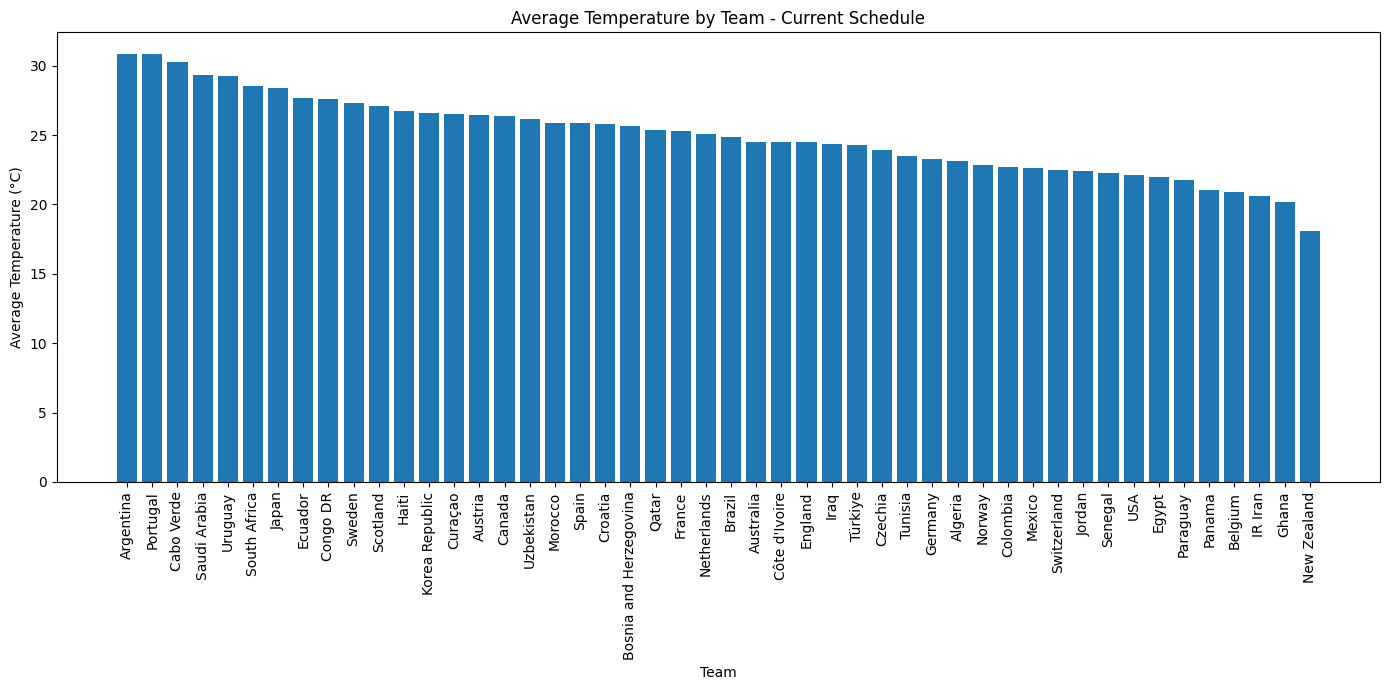

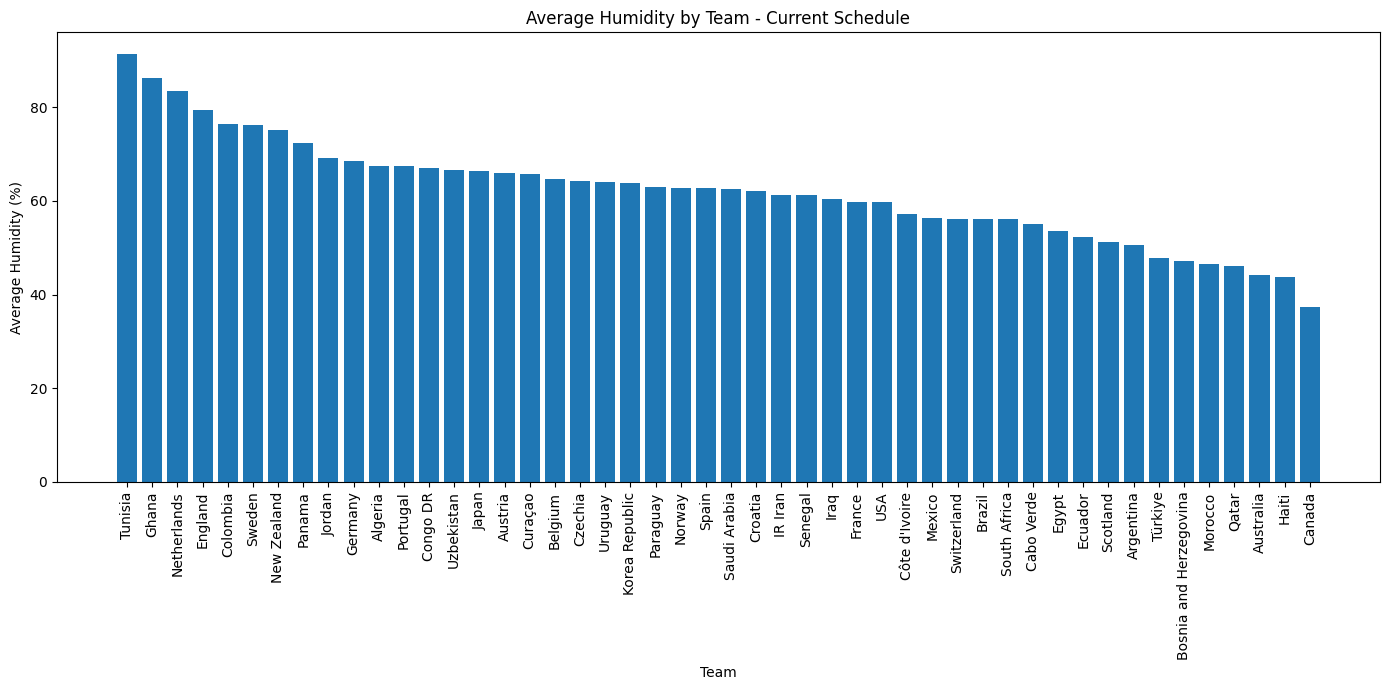

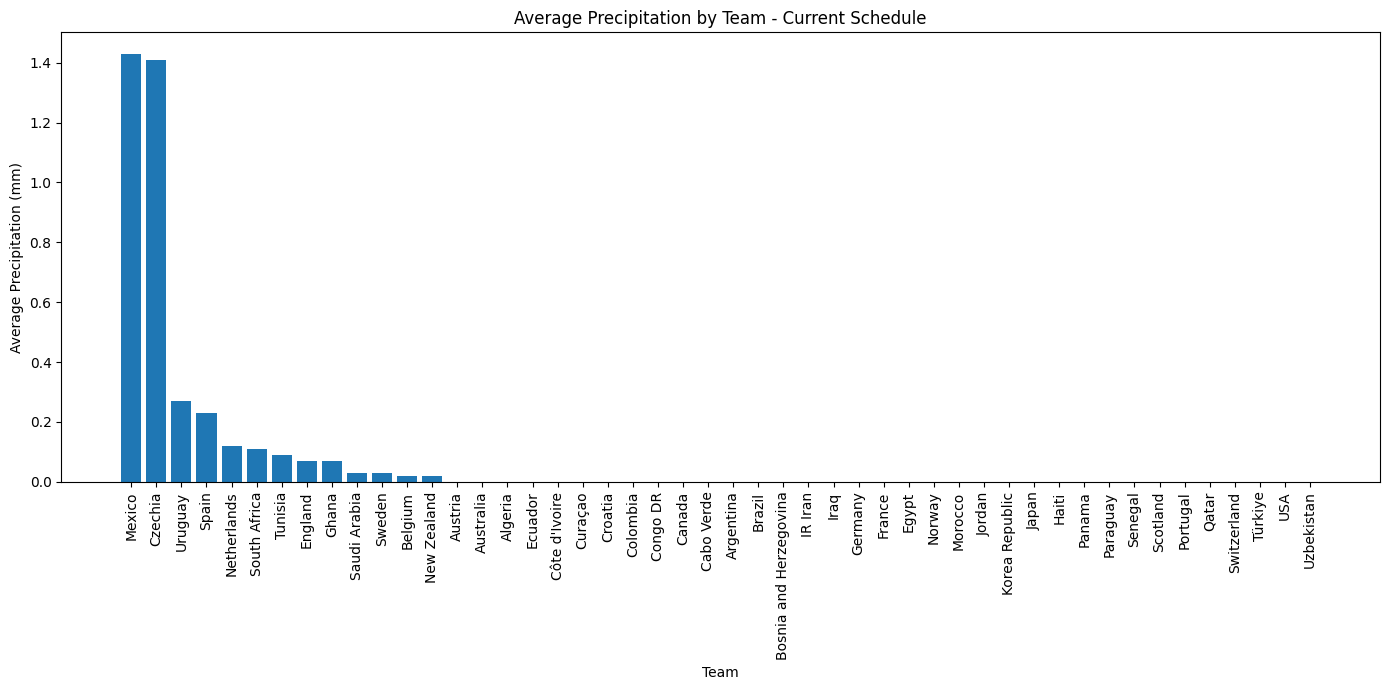

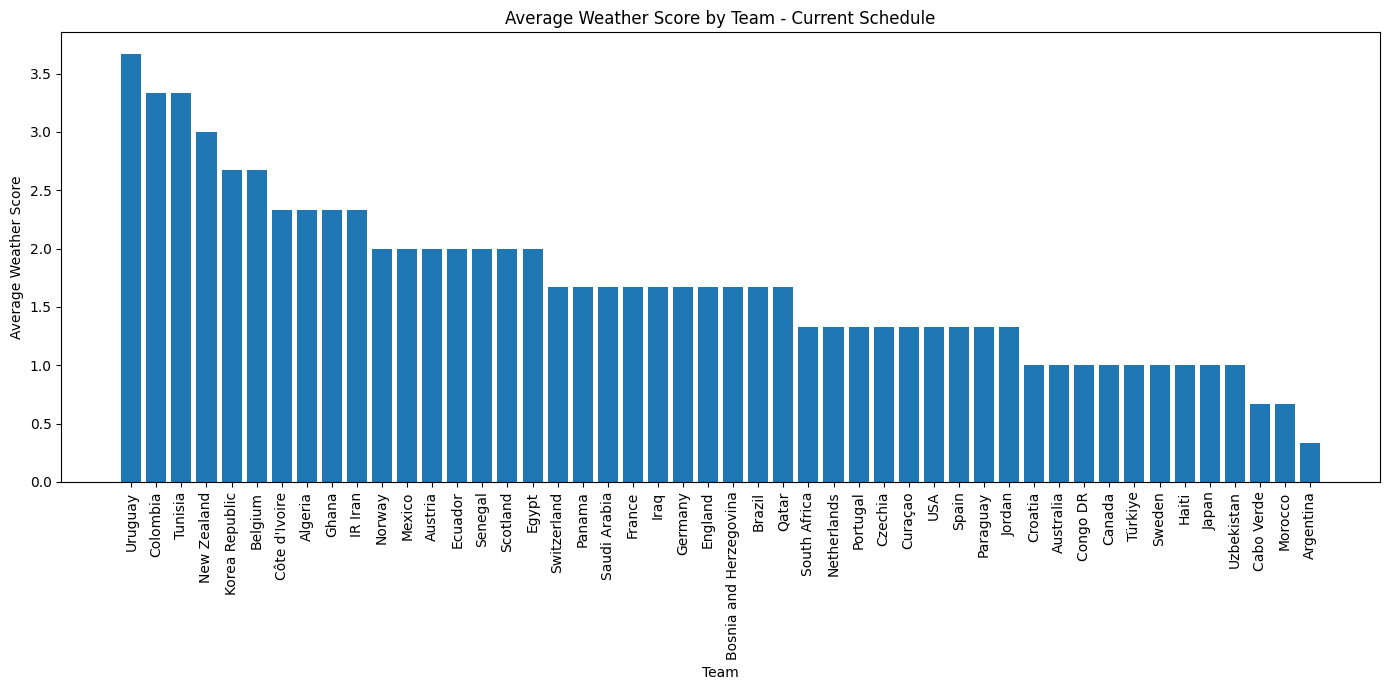

In [ ]:
#graphs
#Used AI to get fimiliar with different graphic functions and how to use them

#Avg temperature by team

temperature_plot = team_weather_summary.sort_values("Avg_Temperature",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(temperature_plot["Team"],temperature_plot["Avg_Temperature"])

plt.title("Average Temperature by Team - Current Schedule")
plt.xlabel("Team")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("current_schedule_avg_temperature.png", dpi=300, bbox_inches="tight")
plt.show()


#Avg humidity by team

humidity_plot = team_weather_summary.sort_values("Avg_Humidity",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(humidity_plot["Team"],humidity_plot["Avg_Humidity"])

plt.title("Average Humidity by Team - Current Schedule")
plt.xlabel("Team")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("current_schedule_avg_humidity.png",dpi=300, bbox_inches="tight")

plt.show()


#Avg Precipitation by team

precipitation_plot = team_weather_summary.sort_values("Avg_Precipitation",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(precipitation_plot["Team"],precipitation_plot["Avg_Precipitation"])

plt.title("Average Precipitation by Team - Current Schedule")
plt.xlabel("Team")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("current_schedule_avg_precipitation.png",dpi=300,bbox_inches="tight")

plt.show()


#Avg Weather Score by team

weather_score_plot = team_weather_summary.sort_values("Avg_Weather_Score",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(weather_score_plot["Team"],weather_score_plot["Avg_Weather_Score"])

plt.title("Average Weather Score by Team - Current Schedule")
plt.xlabel("Team")
plt.ylabel("Average Weather Score")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("current_schedule_avg_weather_score.png",dpi=300,bbox_inches="tight")

plt.show()

In [194]:
team_rows_model3 = []

for index, row in model3_df.iterrows():
    # Team 1
    team_rows_model3.append({
        "Team": row["Team 1"],
        "Match_ID": row["Match_ID"],
        "City": row["City"],
        "Stadium": row["Stadium"],
        "Date": row["Date"],
        "Kickoff Hour": row["Kickoff Hour"],
        "Indoor": row["Indoor"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Rain (mm)": row["Rain (mm)"],
        "Weather Score": row["Weather Score"]
    })

    # Team 2
    team_rows_model3.append({
        "Team": row["Team 2"],
        "Match_ID": row["Match_ID"],
        "City": row["City"],
        "Stadium": row["Stadium"],
        "Date": row["Date"],
        "Kickoff Hour": row["Kickoff Hour"],
        "Indoor": row["Indoor"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Rain (mm)": row["Rain (mm)"],
        "Weather Score": row["Weather Score"]
    })


model3_weather_df = pd.DataFrame(team_rows_model3)

model3_weather_summary = (
    model3_weather_df.groupby("Team").agg(
        Matches=("Match_ID", "count"),
        Avg_Temperature=("Temperature", "mean"),
        Avg_Humidity=("Humidity", "mean"),
        Avg_Precipitation=("Rain (mm)", "mean"),
        Avg_Weather_Score=("Weather Score", "mean")).reset_index()
)

# Round
model3_weather_summary["Avg_Temperature"] = (model3_weather_summary["Avg_Temperature"].round(2))

model3_weather_summary["Avg_Humidity"] = (model3_weather_summary["Avg_Humidity"].round(2))

model3_weather_summary["Avg_Precipitation"] = (model3_weather_summary["Avg_Precipitation"].round(2))

model3_weather_summary["Avg_Weather_Score"] = (model3_weather_summary["Avg_Weather_Score"].round(2))


# Sort alphabetically by team
model3_weather_summary = model3_weather_summary.sort_values("Team")

model3_weather_summary

,Team,Matches,Avg_Temperature,Avg_Humidity,Avg_Precipitation,Avg_Weather_Score
0,Algeria,3,19.27,51.99,0.00,0.00
1,Argentina,3,25.90,49.57,0.00,0.33
2,Australia,3,30.87,61.23,0.04,0.67
3,Austria,3,19.73,53.94,0.00,0.00
4,Belgium,3,18.67,54.84,0.00,0.00
5,Bosnia and Herzegovina,3,22.40,58.98,0.00,0.33
6,Brazil,3,21.33,55.27,0.00,0.33
7,Cabo Verde,3,31.17,57.85,0.00,0.00
8,Canada,3,22.80,57.74,0.00,0.33
9,Colombia,3,28.00,54.08,0.00,1.33


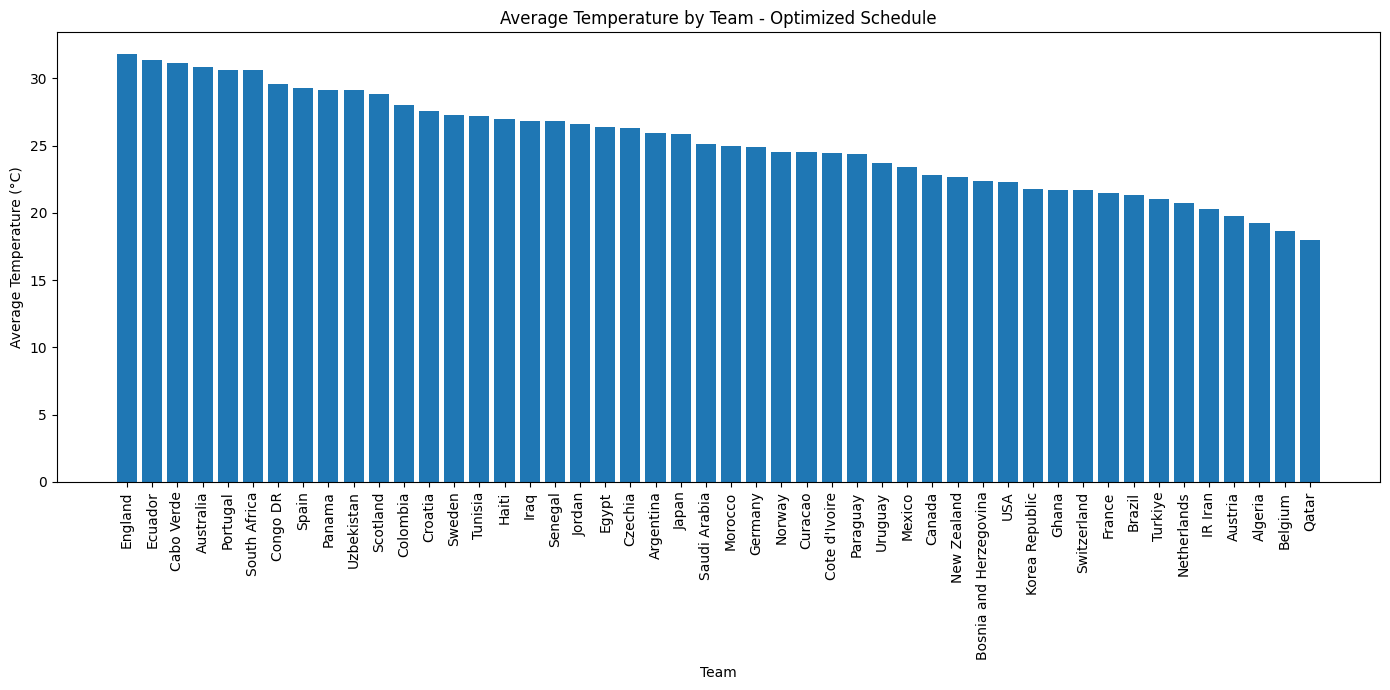

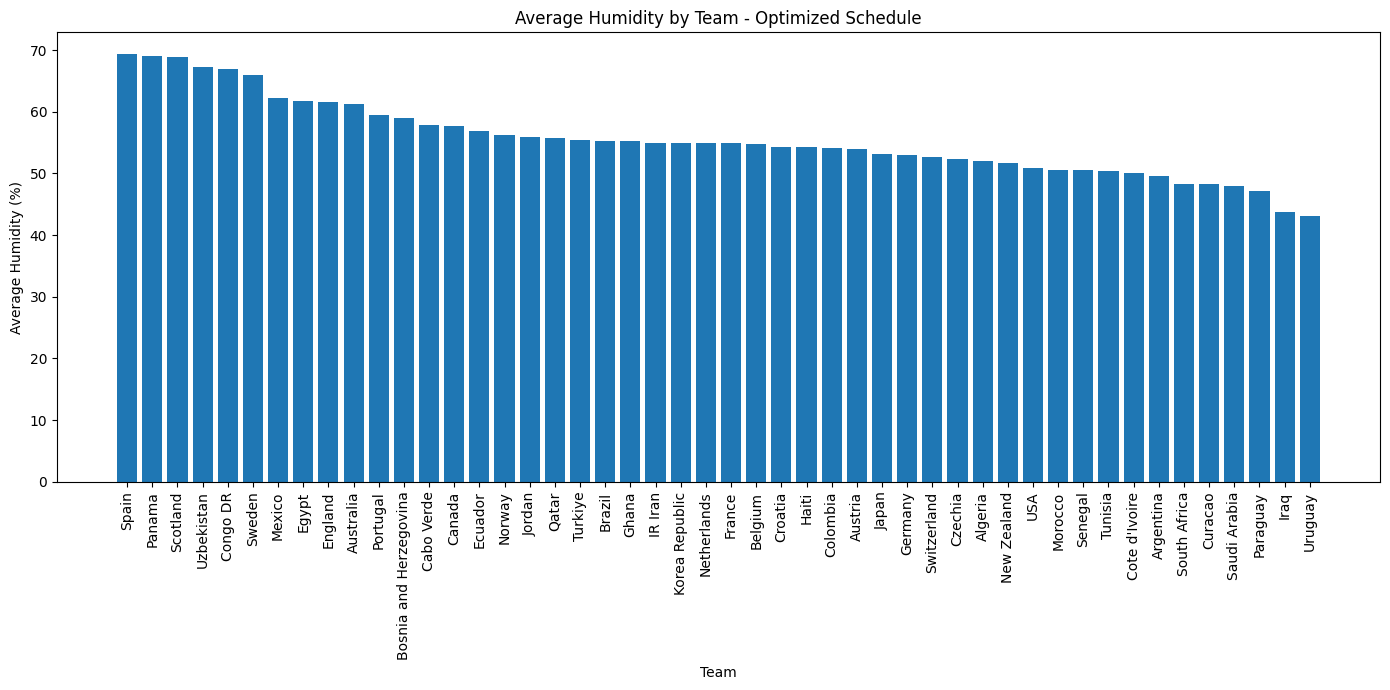

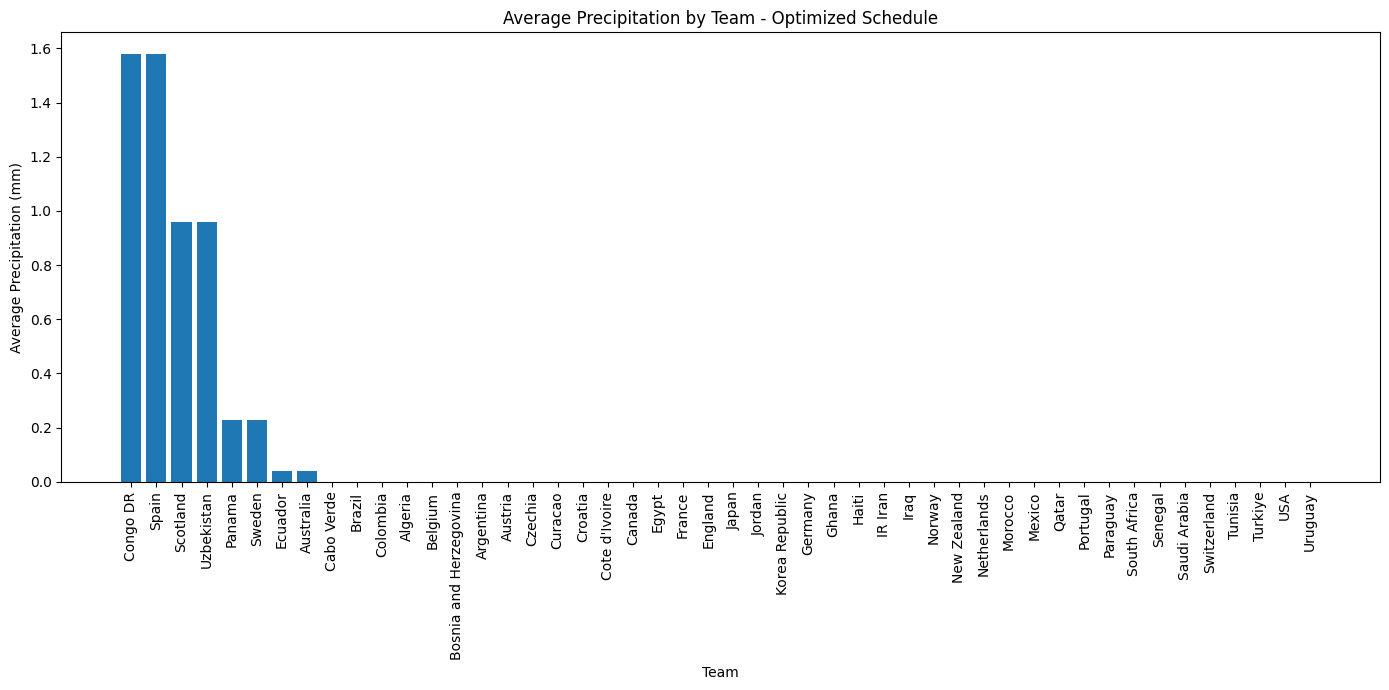

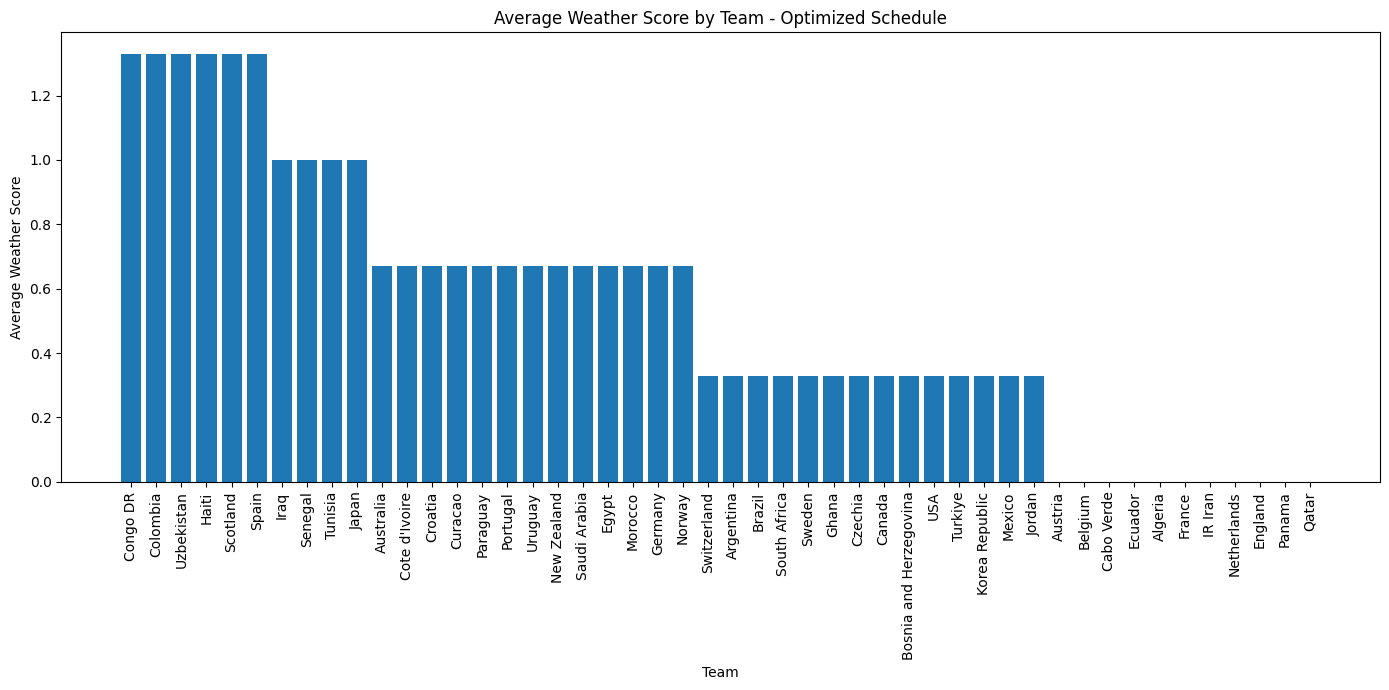

In [193]:
#graphs
#Used AI to get fimiliar with different graphic functions and how to use them

#Avg temperature by team

temperature_plot = model3_weather_summary.sort_values("Avg_Temperature",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(temperature_plot["Team"],temperature_plot["Avg_Temperature"])

plt.title("Average Temperature by Team - Optimized Schedule")
plt.xlabel("Team")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("optimized_schedule_avg_temperature.png", dpi=300, bbox_inches="tight")
plt.show()


#Avg humidity by team

humidity_plot = model3_weather_summary.sort_values("Avg_Humidity",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(humidity_plot["Team"],humidity_plot["Avg_Humidity"])

plt.title("Average Humidity by Team - Optimized Schedule")
plt.xlabel("Team")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("optimized_schedule_avg_humidity.png",dpi=300, bbox_inches="tight")

plt.show()


#Avg Precipitation by team

precipitation_plot = model3_weather_summary.sort_values("Avg_Precipitation",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(precipitation_plot["Team"],precipitation_plot["Avg_Precipitation"])

plt.title("Average Precipitation by Team - Optimized Schedule")
plt.xlabel("Team")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("optimized_schedule_avg_precipitation.png",dpi=300,bbox_inches="tight")

plt.show()


#Avg Weather Score by team

weather_score_plot = model3_weather_summary.sort_values("Avg_Weather_Score",ascending=False)

plt.figure(figsize=(14, 7))

plt.bar(weather_score_plot["Team"],weather_score_plot["Avg_Weather_Score"])

plt.title("Average Weather Score by Team - Optimized Schedule")
plt.xlabel("Team")
plt.ylabel("Average Weather Score")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("optimized_schedule_avg_weather_score.png",dpi=300,bbox_inches="tight")

plt.show()